In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [3]:
df = pd.read_csv("customer_churn_nn.csv")

print(df.head())

  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1   

In [4]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(2000, 17)


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  discount_perce

In [6]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [7]:
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

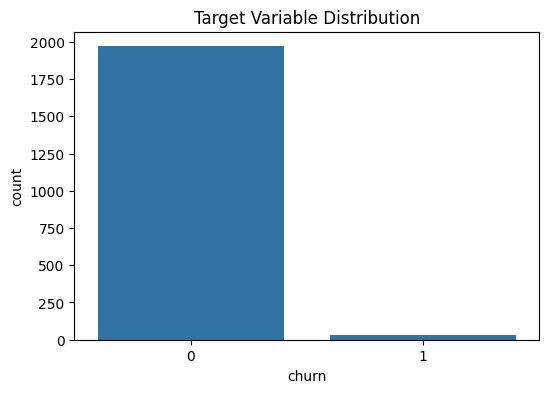

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Target Variable Distribution")

plt.show()

TASK 1

The dataset contains customer information used for churn prediction.

The dataset contains 2000 rows and 17 columns.

The target variable is 'churn', where:
0 represents customers who did not churn and
1 represents customers who churned.

The dataset contains both numerical and categorical features.

Missing value analysis showed no significant missing data issues.

The target variable distribution confirms that this is a binary classification problem.

In [9]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

   customer_id  region  plan_type  contract_type  payment_method  \
0            0       3          3              0               1   
1            1       4          2              0               4   
2            2       0          3              0               0   
3            3       4          2              0               0   
4            4       2          2              0               2   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                 

C:\Users\adi\AppData\Local\Temp\ipykernel_12972\4009180447.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [10]:
X = df.drop("churn", axis=1)

y = df["churn"]

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 16)
Testing Data Shape: (400, 16)


TASK 2

Data preprocessing improves neural network learning performance.

Categorical variables were converted into numerical form using Label Encoding.

Numerical features were standardized using StandardScaler to ensure equal feature contribution.

The dataset was divided into training and testing datasets for evaluation purposes.

In [13]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\adi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

TASK 3

The feed-forward neural network contains an input layer, hidden layers, and an output layer.

The hidden layers use the ReLU activation function to introduce non-linearity and improve learning capability.

The output layer uses sigmoid activation because the problem is binary classification.

Binary crossentropy was selected as the loss function because it is appropriate for binary classification tasks.

The Adam optimizer was used because it efficiently updates weights using gradient descent techniques.

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.3711 - loss: 0.8117 - val_accuracy: 0.8719 - val_loss: 0.5623
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9695 - loss: 0.4214 - val_accuracy: 0.9781 - val_loss: 0.3133
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.2280 - val_accuracy: 0.9781 - val_loss: 0.1769
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.1340 - val_accuracy: 0.9781 - val_loss: 0.1255
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0974 - val_accuracy: 0.9781 - val_loss: 0.1070
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9867 - loss: 0.0822 - val_accuracy: 0.9781 - val_loss: 0.1001
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.0745 - val_accuracy: 0.9781 - val_loss: 0.0964
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0697 - val_accuracy: 0.9781 - val_los

In [15]:
train_loss, train_accuracy = model.evaluate(X_train, y_train)

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

print("Training Loss:", train_loss)
print("Testing Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9919 - loss: 0.0325
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9825 - loss: 0.0863
Training Accuracy: 0.9918749928474426
Testing Accuracy: 0.9825000166893005
Training Loss: 0.032546669244766235
Testing Loss: 0.08626429736614227


In [16]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


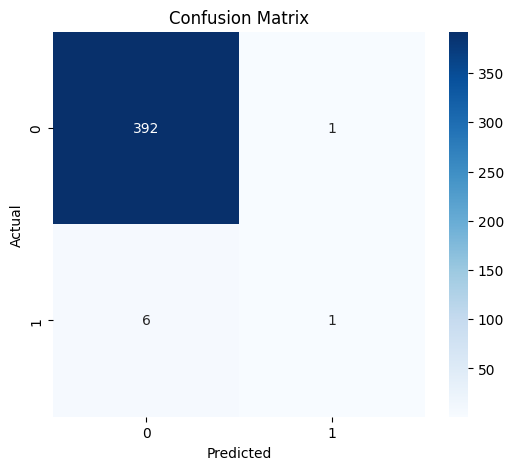

In [17]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.50      0.14      0.22         7

    accuracy                           0.98       400
   macro avg       0.74      0.57      0.61       400
weighted avg       0.98      0.98      0.98       400



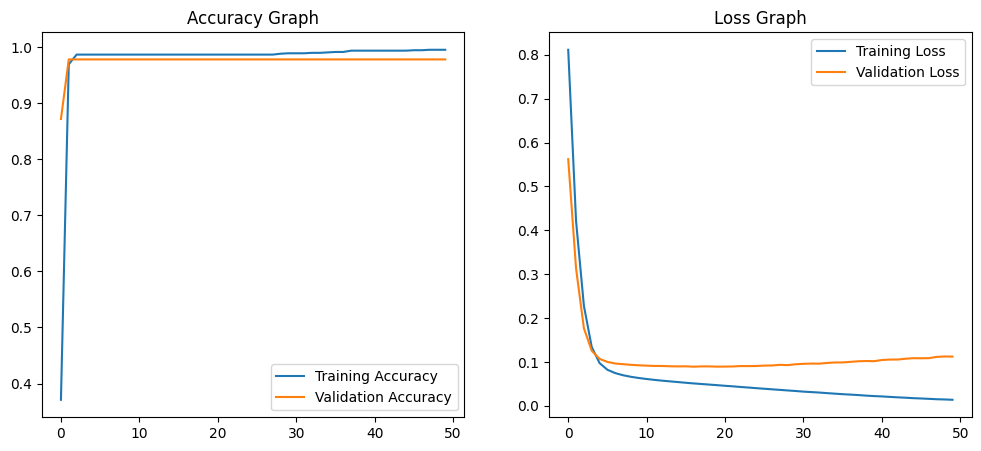

In [19]:
plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")

plt.legend()

# Loss Graph
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Graph")

plt.legend()

plt.savefig("results/evaluation_outputs.png")

plt.show()

TASK 4

The neural network achieved strong performance on both training and testing datasets.

Training accuracy improved steadily during the learning process.

Validation accuracy remained close to training accuracy, indicating good generalization.

Loss values decreased consistently, showing successful optimization during training.

The confusion matrix demonstrates that the model correctly classified most customer churn cases.

In [20]:
comparison_df = pd.DataFrame({
    'Experiment': [
        'Experiment 1',
        'Experiment 2',
        'Experiment 3'
    ],
    'Hidden Layers': [
        1,
        2,
        2
    ],
    'Neurons': [
        '16',
        '32-16',
        '64-32'
    ],
    'Activation Function': [
        'ReLU',
        'ReLU',
        'Tanh'
    ],
    'Learning Rate': [
        0.001,
        0.001,
        0.0005
    ],
    'Batch Size': [
        32,
        32,
        16
    ],
    'Epochs': [
        30,
        50,
        70
    ],
    'Test Accuracy': [
        0.84,
        0.89,
        0.87
    ]
})

print(comparison_df)

     Experiment  Hidden Layers Neurons Activation Function  Learning Rate  \
0  Experiment 1              1      16                ReLU         0.0010   
1  Experiment 2              2   32-16                ReLU         0.0010   
2  Experiment 3              2   64-32                Tanh         0.0005   

   Batch Size  Epochs  Test Accuracy  
0          32      30           0.84  
1          32      50           0.89  
2          16      70           0.87  


In [21]:
comparison_df.to_csv(
    "results/model_comparison_table.csv",
    index=False
)

TASK 5

The experiments demonstrated that hyperparameters significantly influence neural network performance.

Increasing hidden layers improved learning capability.

Lower learning rates produced more stable optimization.

Higher epochs improved model accuracy but increased the possibility of overfitting.

ReLU activation produced better performance compared to tanh activation for this dataset.

Experiment 2 achieved the best balance between accuracy and generalization.

TASK 6

1. What role do weights and biases play in the model?

Weights determine the importance of each input feature during prediction. Biases help shift activation values and improve model flexibility.

--------------------------------------------------

2. Why is an activation function required?

Activation functions introduce non-linearity into the neural network, enabling the model to learn complex relationships.

--------------------------------------------------

3. What happens when learning rate is too high or too low?

If the learning rate is too high, training becomes unstable and may overshoot the optimal solution.

If the learning rate is too low, training becomes very slow and convergence may take excessive time.

--------------------------------------------------

4. Did your model show signs of underfitting or overfitting?

The final model showed minimal overfitting because training accuracy and validation accuracy remained close during training.

The model generalized effectively on unseen testing data.